Các kỹ thuật áp dụng gồm:
- Chọn lọc đặc trưng (Feature Selection)
    + Loại bỏ đặc trưng đệ quy kết hợp kiểm định chéo (RFECV)
    + Ngưỡng phương sai (Variance Threshold)
    + Hệ số tương quan (Correlation Coefficient)
    + Độ quan trọng đặc trưng từ Random Forest (Random Forest Feature Importance)
- Giảm chiều dữ liệu (Dimensionality Reduction)
    + Phân tích thành phần chính (PCA)
    + Phân rã giá trị suy biến (SVD)
    + Phân tích phân biệt tuyến tính (LDA)

In [3]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold

from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import RandomForestRegressor

from sklearn.feature_selection import (
    RFECV,
    VarianceThreshold
)

from sklearn.decomposition import PCA, TruncatedSVD

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

from sklearn.metrics import (
    mean_squared_error,
    r2_score
)

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)

In [4]:
df = pd.read_csv("salary_synthetic.csv")

print("Dataset shape:", df.shape)

display(df.head())

Dataset shape: (2000, 15)


,age,gender,education,experience_years,role_seniority,company_size,location_tier,skills_count,certifications,worked_remote,last_promotion_years_ago,salary_bdt,recent_project_description_length,survey_date,recent_note
0,33,Male,M.Sc,6.0,Senior,Enterprise,Tier-2,1.0,2.0,1,0.0,145185,57.0,2024-11-15,Worked on microservices deployment
1,29,Male,M.Sc,9.0,Junior,Enterprise,Remote,5.0,0.0,1,0.0,121262,50.0,2024-03-08,Built ML pipeline for preprocessing
2,34,Male,B.Sc+Cert,NaN,Lead,Enterprise,Remote,5.0,1.0,1,5.0,184875,50.0,2024-09-01,Experience in data cleaning and ETL
3,39,Male,B.Sc,16.0,Mid,Enterprise,Tier-1,5.0,0.0,1,3.0,180105,59.0,2024-01-26,Contributed to open-source NLP repo
4,29,Female,B.Sc,8.0,Junior,SME,Tier-1,5.0,2.0,0,7.0,114750,NaN,2023-12-08,Built ML pipeline for preprocessing


Tập dữ liệu bao gồm 2.000 dòng quan sát và 15 cột.
Biến mục tiêu cho bài phân tích chính là salary_bdt.
Tập dữ liệu chứa nhiều loại biến khác nhau:
    - Các biến định lượng (numerical): ví dụ như age (tuổi), experience_years (số năm kinh nghiệm) và skills_count (số lượng kỹ năng).
    - Các biến phân loại (categorical): ví dụ như gender (giới tính), education (trình độ học vấn) và company_size (quy mô công ty).
    - Một biến nhị phân (binary): worked_remote (làm việc từ xa).
    - Một biến ngày tháng (date): survey_date (ngày khảo sát).
    - Một biến văn bản (text): recent_note (ghi chú gần đây).

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 15 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   age                                2000 non-null   int64  
 1   gender                             2000 non-null   str    
 2   education                          1900 non-null   str    
 3   experience_years                   1840 non-null   float64
 4   role_seniority                     2000 non-null   str    
 5   company_size                       2000 non-null   str    
 6   location_tier                      2000 non-null   str    
 7   skills_count                       1800 non-null   float64
 8   certifications                     1920 non-null   float64
 9   worked_remote                      2000 non-null   int64  
 10  last_promotion_years_ago           1880 non-null   float64
 11  salary_bdt                         2000 non-null   int64  
 12  rec

In [6]:
display(df.describe(include="all").T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,2000.0,NaN,NaN,NaN,30.3675,5.721172,20.0,26.0,30.0,34.0,53.0
gender,2000,3,Male,1437,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education,1900,5,B.Sc,1070,NaN,NaN,NaN,NaN,NaN,NaN,NaN
experience_years,1840.0,NaN,NaN,NaN,7.729348,5.676872,0.0,3.0,7.0,11.0,29.0
role_seniority,2000,4,Mid,791,NaN,NaN,NaN,NaN,NaN,NaN,NaN
company_size,2000,3,SME,810,NaN,NaN,NaN,NaN,NaN,NaN,NaN
location_tier,2000,4,Tier-1,813,NaN,NaN,NaN,NaN,NaN,NaN,NaN
skills_count,1800.0,NaN,NaN,NaN,5.043333,2.211021,1.0,4.0,5.0,6.0,14.0
certifications,1920.0,NaN,NaN,NaN,1.008333,0.996049,0.0,0.0,1.0,2.0,7.0
worked_remote,2000.0,NaN,NaN,NaN,0.3845,0.486599,0.0,0.0,0.0,1.0,1.0


In [7]:
# Missing values
missing = df.isnull().sum()

missing_table = pd.DataFrame({
    "Missing_Count": missing,
    "Missing_Percentage": missing / len(df) * 100
})

missing_table = missing_table[
    missing_table["Missing_Count"] > 0
].sort_values(
    "Missing_Count",
    ascending=False
)

display(missing_table)

,Missing_Count,Missing_Percentage
recent_note,300,15.0
recent_project_description_length,240,12.0
skills_count,200,10.0
experience_years,160,8.0
last_promotion_years_ago,120,6.0
education,100,5.0
certifications,80,4.0


Tập dữ liệu chứa các giá trị bị thiếu ở một số biến.

Các giá trị thiếu này không tập trung ở biến mục tiêu salary_bdt. Đây là một điểm quan trọng vì biến mục tiêu cần phải luôn đầy đủ phục vụ cho việc học có giám sát (supervised learning).

Các giá trị thiếu chủ yếu xuất hiện ở:
    - education (trình độ học vấn)
    - experience_years (số năm kinh nghiệm)
    - skills_count (số lượng kỹ năng)
    - certifications (chứng chỉ)
     -last_promotion_years_ago (số năm kể từ lần thăng chức gần nhất)
     -recent_project_description_length (độ dài mô tả dự án gần đây)
     -recent_note (ghi chú gần đây)
-> Thay vì xóa bỏ toàn bộ các dòng có chứa giá trị thiếu, chúng ta sẽ điền khuyết (impute) các biến định lượng bằng giá trị trung vị (median) và các biến phân loại bằng giá trị xuất hiện nhiều nhất (mode).
Cách xử lý này giúp bảo toàn số lượng quan sát phục vụ cho các quy trình lựa chọn đặc trưng (feature selection) tiếp theo.

In [8]:
# Chia các nhóm dữ liệu dạng số để xử lý missing
numeric_cols = [
    "age",
    "experience_years",
    "skills_count",
    "certifications",
    "last_promotion_years_ago",
    "recent_project_description_length"
]

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

In [9]:
# Chia các nhóm dữ liệu dạng phân loại để xử lý missing
categorical_cols = [
    "gender",
    "education",
    "role_seniority",
    "company_size",
    "location_tier"
]

for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [10]:
# Check lại missing values
print("Total missing values:", df.isnull().sum().sum())

display(df.isnull().sum())

Total missing values: 300


age                                    0
gender                                 0
education                              0
experience_years                       0
role_seniority                         0
company_size                           0
location_tier                          0
skills_count                           0
certifications                         0
worked_remote                          0
last_promotion_years_ago               0
salary_bdt                             0
recent_project_description_length      0
survey_date                            0
recent_note                          300
dtype: int64

Cột recent_note là dạng dữ liệu text khác với các dạng dữ liệu số của các cột như : age, experience_years, education,... không thể xử lý bằng cách thêm median, mode. Không thể áp dụng các thuật toán yêu cầu tính toán của giảm số chiều và chọn lọc đặc trưng, ngoài ra có số lượng missing chiếm 15% có thể gây nhiễu trong thông tin , để tránh sảnh hưởng số chiều -> drop cột recent_note

In [11]:
df = df.drop(columns=["recent_note"])

Cột survet_date là dạng dữ liệu string ko phù hợp với các thuật toán và ko thể tính trực tiếp trên chuỗi thời gian, nhưng thay vì xóa bỏ như cột recent_note thì cột survey_date liên quan và tác động đến salary_bdt , liên quan đến lương định kỳ. Vậy nên cần trích xuất dữ liệu quan trọng chia thành survey_year and survey_month để chuyển về dạng sữ liệu số , để có thể áp dụng các thuật toán tính toán , và sau đó xóa cột survey_date. 

In [12]:
df["survey_date"] = pd.to_datetime(df["survey_date"])

df["survey_year"] = df["survey_date"].dt.year
df["survey_month"] = df["survey_date"].dt.month

df = df.drop(columns=["survey_date"])

In [14]:
target = "salary_bdt"

X = df.drop(columns=[target])
y = df[target]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (2000, 14)
y shape: (2000,)


Vì salary_bdt là biến số liên tục nên model cần sử dụng là model RandomForestRegressor đánh giá dự đoán số liên tục

Sử dụng One-hot-enoding để chuẩn hóa các cột trong category thành dạng dữ liệu nhị phân để áp dụng các thuật toán có yêu cầu dữ liệu dưới dạng số.

In [15]:
X = pd.get_dummies(
    X,
    columns=categorical_cols,
    drop_first=True
)

X = X.astype(float)

print("Encoded feature matrix shape:", X.shape)

display(X.head())

Encoded feature matrix shape: (2000, 23)


,age,experience_years,skills_count,certifications,worked_remote,last_promotion_years_ago,recent_project_description_length,survey_year,survey_month,gender_Male,gender_Other,education_B.Sc+Cert,education_M.Eng,education_M.Sc,education_PhD,role_seniority_Lead,role_seniority_Mid,role_seniority_Senior,company_size_SME,company_size_Startup,location_tier_Tier-1,location_tier_Tier-2,location_tier_Tier-3
0,33.0,6.0,1.0,2.0,1.0,0.0,57.0,2024.0,11.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1,29.0,9.0,5.0,0.0,1.0,0.0,50.0,2024.0,3.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,34.0,7.0,5.0,1.0,1.0,5.0,50.0,2024.0,9.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,39.0,16.0,5.0,0.0,1.0,3.0,59.0,2024.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
4,29.0,8.0,5.0,2.0,0.0,7.0,59.0,2023.0,12.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0


Phân chia tập dữ liệu huấn luyện và kiểm thử Tập dữ liệu được chia thành: - 80% dữ liệu huấn luyện - 20% dữ liệu kiểm thử Tập huấn luyện được sử dụng để thực hiện chọn lọc đặc trưng và giảm chiều dữ liệu. Tập kiểm thử được giữ riêng biệt để có thể thực hiện chuyển đổi cuối cùng và đánh giá mô hình trên các quan sát chưa được nhìn thấy. Điều này giúp tránh việc đánh giá mô hình trên cùng một tập dữ liệu được sử dụng để chọn lọc đặc trưng.

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (1600, 23)
X_test : (400, 23)
y_train: (1600,)
y_test : (400,)


In [18]:
# Chọn model huấn luyện
baseline_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

baseline_model.fit(X_train, y_train)

baseline_pred = baseline_model.predict(X_test)

baseline_rmse = np.sqrt(
    mean_squared_error(y_test, baseline_pred)
)

baseline_r2 = r2_score(
    y_test,
    baseline_pred
)

print("Baseline RMSE:", baseline_rmse)
print("Baseline R²  :", baseline_r2)

Baseline RMSE: 30502.97539460967
Baseline R²  : 0.7048768285637812


Sử dụng model để kiểm tra toàn bộ sai số trước khi áp dụng các thuật toán.

1. Sử dụng RFECV 
- RFECV kết hợp phương pháp loại bỏ đặc trưng đệ quy (RFE) với phương pháp kiểm định chéo.
- RFE bao gồm các bước :
    + Fit a model.
    + Obtain feature importance scores.
    + Remove the least important feature.
    + Repeat the process.
- Ngoài ra, RFECV còn đánh giá số lượng khác nhau của các đặc trưng được chọn bằng phương pháp kiểm chứng chéo.

In [19]:
rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

In [20]:
cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [21]:
rfecv = RFECV(
    estimator=rf_model,
    step=1,
    min_features_to_select=1,
    cv=cv,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

rfecv.fit(X_train, y_train)

,estimator estimator: ``Estimator`` instanceA supervised learning estimator with a ``fit`` method that providesinformation about feature importance either through a ``coef_``attribute or through a ``feature_importances_`` attribute.,RandomForestR...ndom_state=42)
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- integer, to specify the number of folds,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. If theestimator is not a classifier or if ``y`` is neither binary nor multiclass,:class:`~sklearn.model_selection.KFold` is used.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value of None changed from 3-fold to 5-fold.",KFold(n_split... shuffle=True)
,"scoring scoring: str or callable, default=NoneScoring method to evaluate the :class:`RFE` selectors' performance. Options:- str: see :ref:`scoring_string_names` for options.- callable: a scorer callable object (e.g., function) with signature ``scorer(estimator, X, y)``. See :ref:`scoring_callable` for details.- `None`: the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.",'neg_mean_squared_error'
,"n_jobs n_jobs: int or None, default=NoneNumber of cores to run in parallel while fitting across folds.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionadded:: 0.18",-1
,"step step: int or float, default=1If greater than or equal to 1, then ``step`` corresponds to the(integer) number of features to remove at each iteration.If within (0.0, 1.0), then ``step`` corresponds to the percentage(rounded down) of features to remove at each iteration.Note that the last iteration may remove fewer than ``step`` features inorder to reach ``min_features_to_select``.",1
,"min_features_to_select min_features_to_select: int, default=1The minimum number of features to be selected. This number of featureswill always be scored, even if the difference between the originalfeature count and ``min_features_to_select`` isn't divisible by``step``... versionadded:: 0.20",1
,"verbose verbose: int, default=0Controls verbosity of output.",0
,"importance_getter importance_getter: str or callable, default='auto'If 'auto', uses the feature importance either through a `coef_`or `feature_importances_` attributes of estimator.Also accepts a string that specifies an attribute name/pathfor extracting feature importance.For example, give `regressor_.coef_` in case of:class:`~sklearn.compose.TransformedTargetRegressor` or`named_steps.clf.feature_importances_` in case of:class:`~sklearn.pipeline.Pipeline` with its last step named `clf`.If `callable`, overrides the default feature importance getter.The callable is passed with the fitted estimator and it shouldreturn importance for each feature... versionadded:: 0.24",'auto'
Name,Type,Value
"cv_results_ cv_results_: dict of ndarraysAll arrays (values of the dictionary) are sorted in ascending orderby the number of features used (i.e., the first element of the arrayrepresents the models that used the least number of features, while thelast element represents the models that used all available features)... versionadded:: 1.0This dictionary contains the following keys:split(k)_test_score : ndarray of shape (n_subsets_of_features,) The cross-validation scores across (k)th fold.mean_test_score : ndarray of shape (n_subsets_of_features,) Mean of scores over the folds.std_test_score : ndarray of shape (n_subsets_of_features,) Standard deviation of scores over the folds.n_features : ndarray of shape (n_subsets_of_features,) Number of features used at

In [22]:
print(
    "Optimal number of features:",
    rfecv.n_features_
)

Optimal number of features: 20


In [23]:
selected_rfecv = X_train.columns[
    rfecv.support_
]

print("Selected features:")
for feature in selected_rfecv:
    print("-", feature)

Selected features:
- age
- experience_years
- skills_count
- certifications
- worked_remote
- last_promotion_years_ago
- recent_project_description_length
- survey_year
- survey_month
- gender_Male
- education_M.Sc
- education_PhD
- role_seniority_Lead
- role_seniority_Mid
- role_seniority_Senior
- company_size_SME
- company_size_Startup
- location_tier_Tier-1
- location_tier_Tier-2
- location_tier_Tier-3


Giải thích kết quả RFECV Giá trị 
- rfecv.n_features_ biểu thị số lượng đặc trưng được RFECV chọn theo quy trình kiểm định chéo.
- rfecv.support_ xác định các đặc trưng gốc nào được chọn.

In [26]:

n_features_range = range(
    rfecv.min_features_to_select,
    rfecv.min_features_to_select + len(rfecv.cv_results_["mean_test_score"])
)

rfecv_results = pd.DataFrame({
    "n_features": n_features_range,
    "mean_test_score": rfecv.cv_results_["mean_test_score"],
    "std_test_score": rfecv.cv_results_["std_test_score"]
})

display(rfecv_results)

,n_features,mean_test_score,std_test_score
0,1,-1.243071e+09,5.779711e+08
1,2,-1.257794e+09,5.617892e+08
2,3,-1.263652e+09,4.599866e+08
3,4,-1.181623e+09,4.758969e+08
4,5,-1.194248e+09,4.814115e+08
5,6,-1.195792e+09,4.906695e+08
6,7,-1.171722e+09,5.066971e+08
7,8,-1.121764e+09,5.157634e+08
8,9,-1.084226e+09,5.086108e+08
9,10,-1.063275e+09,4.893359e+08


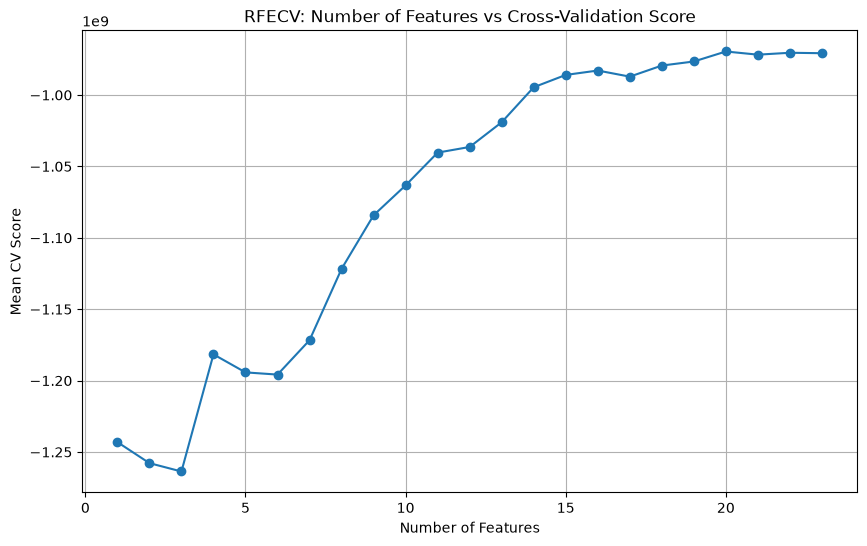

In [27]:
plt.figure(figsize=(10, 6))

plt.plot(
    rfecv_results["n_features"],
    rfecv_results["mean_test_score"],
    marker="o"
)

plt.xlabel("Number of Features")
plt.ylabel("Mean CV Score")
plt.title("RFECV: Number of Features vs Cross-Validation Score")

plt.grid(True)
plt.show()

2. Variance Threshold
- Là một phương pháp trích chọn đặc trưng thuộc nhóm lọc (filter-based).
- Một đặc trưng có phương sai cực kỳ thấp nghĩa là giá trị của nó gần như không thay đổi qua các quan sát. Một đặc trưng như vậy cung cấp rất ít thông tin mang tính phân biệt.
-> Do đó, các đặc trưng có phương sai nằm dưới một ngưỡng định trước có thể được loại bỏ.

In [28]:
variance_selector = VarianceThreshold(
    threshold=0.01
)

X_train_vt = variance_selector.fit_transform(X_train)

selected_vt = X_train.columns[
    variance_selector.get_support()
]

print("Original number of features:", X_train.shape[1])
print("Remaining features:", X_train_vt.shape[1])

print("\nSelected features:")
for feature in selected_vt:
    print("-", feature)

Original number of features: 23
Remaining features: 23

Selected features:
- age
- experience_years
- skills_count
- certifications
- worked_remote
- last_promotion_years_ago
- recent_project_description_length
- survey_year
- survey_month
- gender_Male
- gender_Other
- education_B.Sc+Cert
- education_M.Eng
- education_M.Sc
- education_PhD
- role_seniority_Lead
- role_seniority_Mid
- role_seniority_Senior
- company_size_SME
- company_size_Startup
- location_tier_Tier-1
- location_tier_Tier-2
- location_tier_Tier-3


Variance Threshold chỉ quan tâm đến phương sai cao và thấp để nó xét việc nên bỏ đi hay giữ lại cột đó, chứ không quan tâm đến việc cột có liên quan đến mục tiêu là salary_bdt hay không. Nếu phương sai cao thì vẫn dc giữ lại, nếu phương sai thấp thì sẽ bị loại bỏ, mặc dù các cột có liên quan hay ko.

3. Hệ số tương quan (Correlation Coefficient)
- Tương quan là một phương pháp trích chọn đặc trưng khác thuộc nhóm lọc (filter-based).
- Giá trị tương quan tuyệt đối giữa từng đặc trưng định lượng với biến mục tiêu salary_bdt sẽ được tính toán.
- Một đặc trưng có giá trị tương quan tuyệt đối càng lớn thì mối quan hệ tuyến tính của nó với mức lương càng mạnh.
- 

In [29]:
corr_data = X_train.copy()

corr_data["salary_bdt"] = y_train.values

correlations = (
    corr_data
    .corr()["salary_bdt"]
    .drop("salary_bdt")
    .sort_values(
        key=lambda x: x.abs(),
        ascending=False
    )
)

display(correlations.to_frame("Correlation"))

,Correlation
experience_years,0.788595
age,0.763698
company_size_Startup,-0.112320
role_seniority_Lead,0.109100
role_seniority_Senior,0.103052
location_tier_Tier-1,0.085565
location_tier_Tier-3,-0.082417
education_M.Eng,0.068544
education_M.Sc,0.064427
education_PhD,0.042358


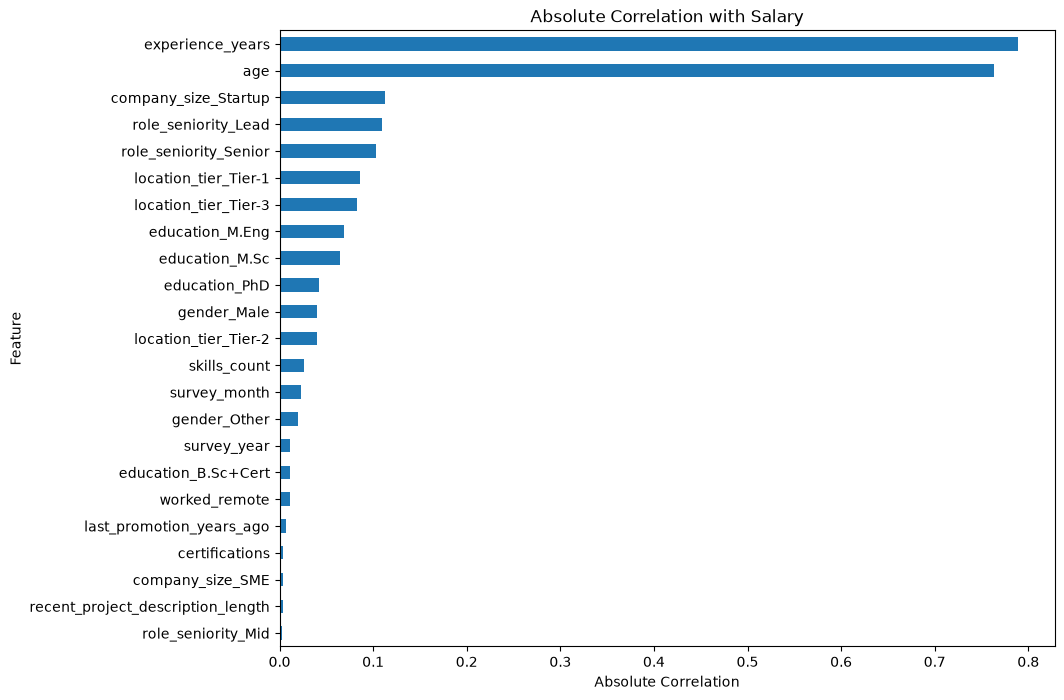

In [30]:
plt.figure(figsize=(10, 8))

correlations.abs().sort_values().plot(
    kind="barh"
)

plt.xlabel("Absolute Correlation")
plt.ylabel("Feature")
plt.title("Absolute Correlation with Salary")

plt.show()

In [ ]:
correlation_threshold = 0.10 

selected_corr = correlations[
    correlations.abs() >= correlation_threshold
].index

print(
    "Correlation threshold:",
    correlation_threshold
)

print(
    "Number of selected features:",
    len(selected_corr)
)

print("\nSelected features:")
for feature in selected_corr:
    print("-", feature)

Correlation threshold: 0.1
Number of selected features: 5

Selected features:
- experience_years
- age
- company_size_Startup
- role_seniority_Lead
- role_seniority_Senior


4. Random Forest Feature Importance
- Là một phương pháp lựa chọn đặc trưng dựa trên mô hình/nhúng. Mô hình Random Forest được huấn luyện trước tiên bằng cách sử dụng dữ liệu huấn luyện. Sau đó, mô hình sẽ cung cấp giá trị độ quan trọng cho mỗi đặc trưng.
- Các đặc điểm có giá trị quan trọng lớn hơn sẽ đóng góp mạnh mẽ hơn vào quá trình dự đoán của mô hình Rừng ngẫu nhiên đã được huấn luyện. Phương pháp này hữu ích vì tập dữ liệu là một bài toán hồi quy và Rừng ngẫu nhiên có thể nắm bắt được các mối quan hệ phi tuyến tính mà tương quan đơn giản có thể không nắm bắt được.

In [32]:
rf_importance_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_importance_model.fit(
    X_train,
    y_train
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"m

In [33]:
importance_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_importance_model.feature_importances_
})

importance_df = importance_df.sort_values(
    "Importance",
    ascending=False
)

display(importance_df)

,Feature,Importance
1,experience_years,0.429200
0,age,0.291793
2,skills_count,0.042200
6,recent_project_description_length,0.038573
8,survey_month,0.037563
5,last_promotion_years_ago,0.027388
3,certifications,0.023576
17,role_seniority_Senior,0.016841
15,role_seniority_Lead,0.014013
19,company_size_Startup,0.009267


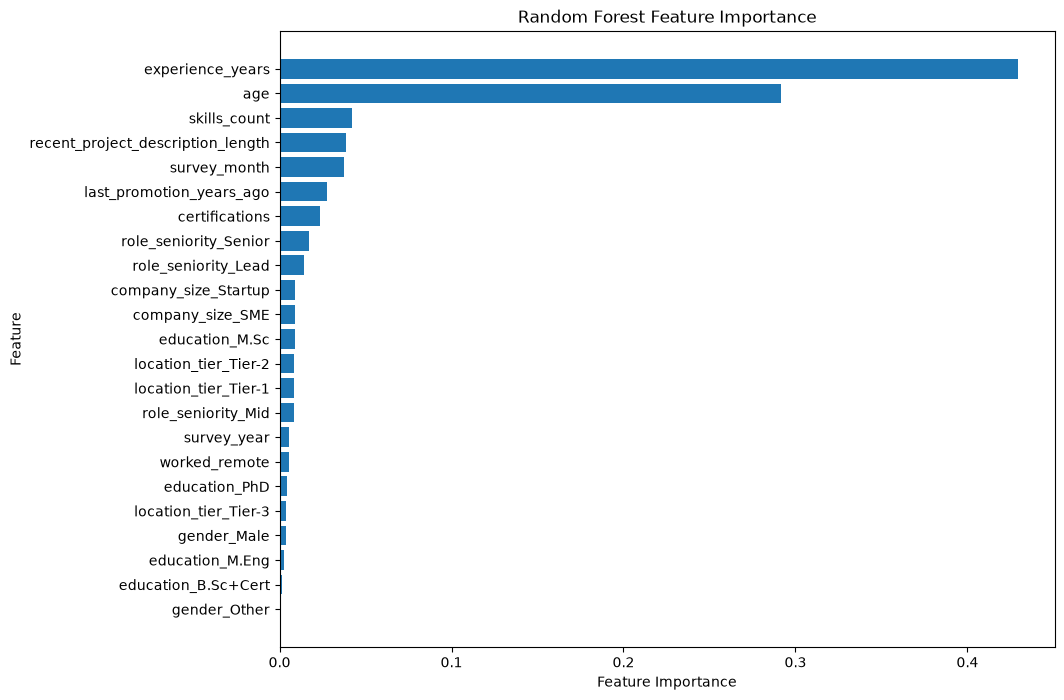

In [34]:
plt.figure(figsize=(10, 8))

plt.barh(
    importance_df["Feature"],
    importance_df["Importance"]
)

plt.gca().invert_yaxis()

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")

plt.show()

In [35]:
n_features_rf = max(
    1,
    X_train.shape[1] // 2
)

selected_rf = (
    importance_df
    .head(n_features_rf)["Feature"]
    .tolist()
)

print("Number of selected features:", len(selected_rf))

print("\nSelected features:")
for feature in selected_rf:
    print("-", feature)

Number of selected features: 11

Selected features:
- experience_years
- age
- skills_count
- recent_project_description_length
- survey_month
- last_promotion_years_ago
- certifications
- role_seniority_Senior
- role_seniority_Lead
- company_size_Startup
- company_size_SME


Phương pháp Random Forest Feature Importance cung cấp thứ tự xếp hạng đặc trưng phụ thuộc vào mô hình (model-dependent).

Khác với hệ số tương quan, phương pháp này có khả năng nắm bắt các mối quan hệ phi tuyến.

Tuy nhiên, mức độ quan trọng của đặc trưng không nên được hiểu một cách máy móc là mối quan hệ nhân quả (causal importance).

In [36]:
feature_selection_summary = pd.DataFrame({
    "Method": [
        "RFECV",
        "Variance Threshold",
        "Correlation",
        "Random Forest Importance"
    ],
    "Number of Selected Features": [
        len(selected_rfecv),
        len(selected_vt),
        len(selected_corr),
        len(selected_rf)
    ]
})

display(feature_selection_summary)

,Method,Number of Selected Features
0,RFECV,20
1,Variance Threshold,23
2,Correlation,5
3,Random Forest Importance,11


So Sánh Các Phương Pháp
RFECV tập trung trực tiếp vào hiệu năng dự đoán thông qua kiểm định chéo.

Variance Threshold chỉ tập trung duy nhất vào phương sai nội tại của bản thân đặc trưng.

Correlation tập trung vào mối liên hệ tuyến tính giữa đặc trưng với mức lương (salary).

Random Forest Importance tập trung vào mức độ mà mô hình Random Forest sau khi huấn luyện sử dụng các đặc trưng đó để đưa ra dự đoán.

In [39]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Scaled training shape:", X_train_scaled.shape)
print("Scaled testing shape :", X_test_scaled.shape)

Scaled training shape: (1600, 23)
Scaled testing shape : (400, 23)


5. PCA (Principal Component Analysis)
dùng để giảm số lượng cột dữ liệu mà vẫn giữ lại được lượng thông tin (phương sai) lớn nhất có thể.


In [40]:
pca = PCA(
    n_components=0.95,
    random_state=42
)

X_train_pca = pca.fit_transform(
    X_train_scaled
)

X_test_pca = pca.transform(
    X_test_scaled
)

print(
    "Original dimensions:",
    X_train.shape[1]
)

print(
    "PCA dimensions:",
    X_train_pca.shape[1]
)

Original dimensions: 23
PCA dimensions: 20


In [41]:
explained_variance = pca.explained_variance_ratio_

pca_variance_df = pd.DataFrame({
    "Component": range(
        1,
        len(explained_variance) + 1
    ),
    "Explained_Variance_Ratio": explained_variance,
    "Cumulative_Variance": np.cumsum(
        explained_variance
    )
})

display(pca_variance_df)

,Component,Explained_Variance_Ratio,Cumulative_Variance
0,1,0.083767,0.083767
1,2,0.068935,0.152703
2,3,0.067085,0.219788
3,4,0.062188,0.281976
4,5,0.055655,0.337632
5,6,0.053939,0.391571
6,7,0.052553,0.444124
7,8,0.048454,0.492577
8,9,0.048204,0.540781
9,10,0.046879,0.587660


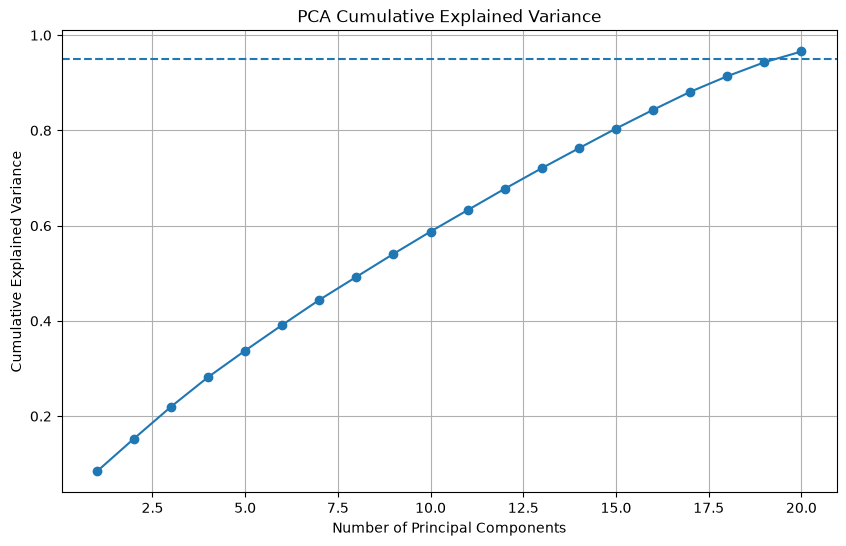

In [42]:
plt.figure(figsize=(10, 6))

plt.plot(
    pca_variance_df["Component"],
    pca_variance_df["Cumulative_Variance"],
    marker="o"
)

plt.axhline(
    0.95,
    linestyle="--"
)

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Cumulative Explained Variance")

plt.grid(True)

plt.show()

6. SVD (Singular Value Decomposition)
Tạo ra một không gian biểu diễn mới có số chiều thấp hơn.

In [43]:
svd = TruncatedSVD(
    n_components=5,
    random_state=42
)

X_train_svd = svd.fit_transform(
    X_train_scaled
)

X_test_svd = svd.transform(
    X_test_scaled
)

print(
    "Original dimensions:",
    X_train.shape[1]
)

print(
    "SVD dimensions:",
    X_train_svd.shape[1]
)

Original dimensions: 23
SVD dimensions: 5


In [44]:
svd_variance = pd.DataFrame({
    "Component": range(
        1,
        len(svd.explained_variance_ratio_) + 1
    ),
    "Explained_Variance_Ratio":
        svd.explained_variance_ratio_,
    "Cumulative_Variance":
        np.cumsum(
            svd.explained_variance_ratio_
        )
})

display(svd_variance)

,Component,Explained_Variance_Ratio,Cumulative_Variance
0,1,0.083762,0.083762
1,2,0.068884,0.152646
2,3,0.067081,0.219727
3,4,0.062155,0.281882
4,5,0.055490,0.337371


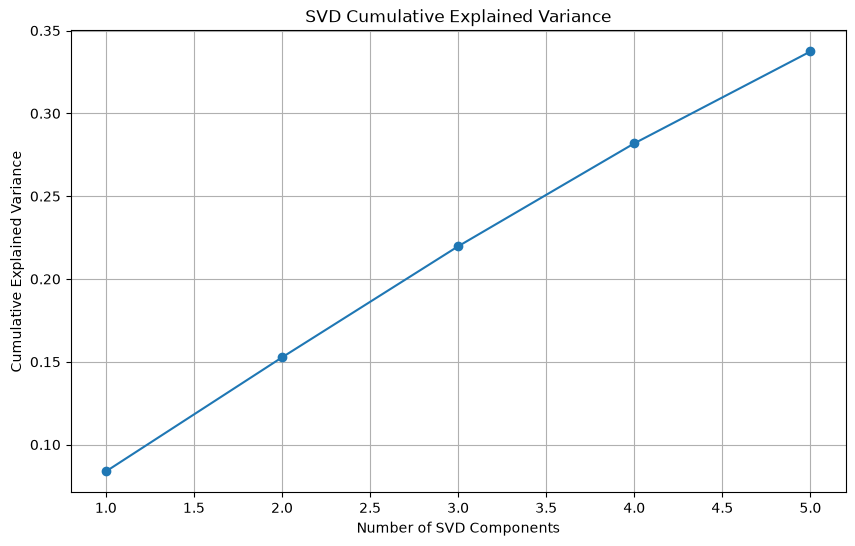

In [45]:
plt.figure(figsize=(10, 6))

plt.plot(
    svd_variance["Component"],
    svd_variance["Cumulative_Variance"],
    marker="o"
)

plt.xlabel("Number of SVD Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("SVD Cumulative Explained Variance")

plt.grid(True)

plt.show()

7. LDA (Linear Discriminant Analysis)
- Biến mục tiêu gốc salary_bdt là một biến liên tục dùng cho bài toán hồi quy (regression). Do đó, nó không thể được sử dụng trực tiếp làm nhãn phân lớp (class label) cho công thức phân loại của thuật toán LDA.
- Biến phân loại thể hiện mức lương (salary level) được tạo ra từ biến mức lương gốc:
    + Thấp (Low)
    + Trung bình (Medium)
    + Cao (High)

In [46]:
df["salary_level"] = pd.qcut(
    df["salary_bdt"],
    q=3,
    labels=[
        "Low",
        "Medium",
        "High"
    ]
)

display(
    df[
        ["salary_bdt", "salary_level"]
    ].head(10)
)

,salary_bdt,salary_level
0,145185,High
1,121262,Medium
2,184875,High
3,180105,High
4,114750,Medium
5,88150,Low
6,210347,High
7,168940,High
8,74069,Low
9,117598,Medium


In [47]:
X_lda = X.copy()

y_lda = df["salary_level"]

X_lda_train, X_lda_test, y_lda_train, y_lda_test = train_test_split(
    X_lda,
    y_lda,
    test_size=0.2,
    random_state=42,
    stratify=y_lda
)

In [48]:
lda_scaler = StandardScaler()

X_lda_train_scaled = lda_scaler.fit_transform(
    X_lda_train
)

X_lda_test_scaled = lda_scaler.transform(
    X_lda_test
)

In [49]:
lda = LinearDiscriminantAnalysis(
    n_components=2
)

X_train_lda = lda.fit_transform(
    X_lda_train_scaled,
    y_lda_train
)

X_test_lda = lda.transform(
    X_lda_test_scaled
)

print(
    "Original dimensions:",
    X_lda_train.shape[1]
)

print(
    "LDA dimensions:",
    X_train_lda.shape[1]
)

Original dimensions: 23
LDA dimensions: 2


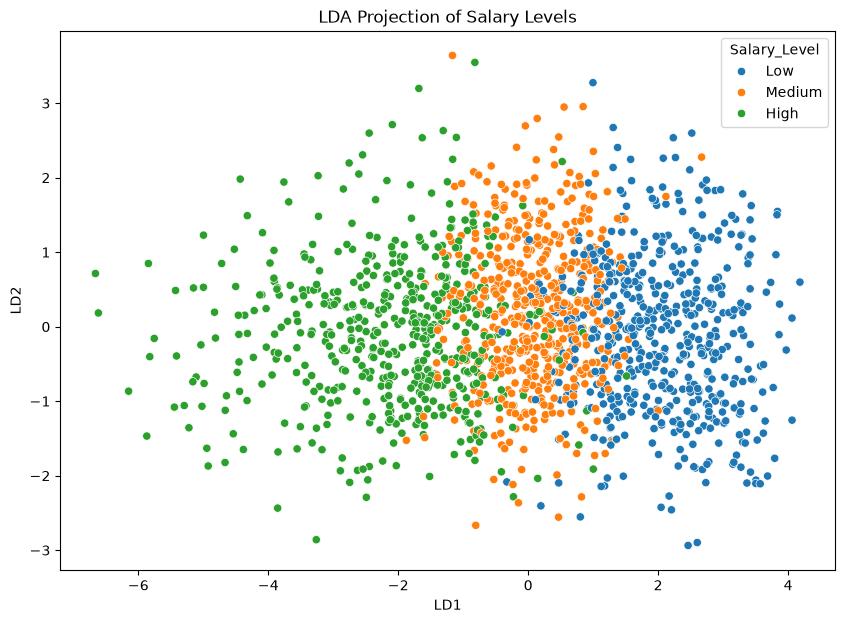

In [50]:
lda_plot = pd.DataFrame({
    "LD1": X_train_lda[:, 0],
    "LD2": X_train_lda[:, 1],
    "Salary_Level": y_lda_train.values
})

plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=lda_plot,
    x="LD1",
    y="LD2",
    hue="Salary_Level"
)

plt.title("LDA Projection of Salary Levels")

plt.show()

-> LDA giúp tạo ko gian biểu diễn các mức lương khác nhau để dễ phân biệt.